# Redes neuronales
---
**Autores:**
- Diego Benjamín García Alfaro
- Mauricio Alejandro Montes Varela

Este notebook es realizado con el objetivo de crear un perceptrón multicapas para el reconocimiento de dígitos manuscritos. Este es un experimento para trabajar con redes neuronales que sirve como problema introductorio; pero eso no quita que sea muy interesante trabajar con las matemáticas detrás de las redes neuronales, especialmente cuando se trata de pasar el conocimiento a la práctica.

**Advertencia: El entrenamiento de la red neuronal se hace de manera local. Las tecnologías son desarrolladas desde cero, así que puede no se encuentran optimizadas para eficiencia computacional; así que, hay celdas que toman mucho tiempo su ejecución y si la computadora en la que se hace es algo lenta, puede causar problemas con esta**

---
## Dependencias

Las dependencias más importantes para poder trabajar son: `NumPY` para trabajar con álgebra lineal y `Matplotlib` para visualización. No se usa librerías de redes neuronales porque siento que se pierde el propósito de aprender cómo funcionan si usamos una librería que ya hizo el trabajo difícil.

In [9]:
# %pip install -r requirements.txt

---
## Importación de datos

Los datos a utilizar son los provistos por la base de datos de MNIST, un banco de datos con 70,000 dígitos escritos a mano en un grid de 28x28 pixeles donde cada dígito está catalogado correctamente. Este dataset consiste de dos grupos: Uno de entrenamiento y otro de pruebas.
- El set de entrenamiento consiste de 60,000 dígitos.
- El set de pruebas consiste de 10,000 dígitos.

El proceso realizado para leer los archivos se encuentra en `pipeline.py` por medio de la clase `Loader`.

In [1]:
import numpy as np
from pipeline import Loader

# digit_train y label_train son Arrays de Numpy
digit_train = Loader.load_mnist_images("mnist-dataset/train-images.idx3-ubyte")
label_train = Loader.load_mnist_labels("mnist-dataset/train-labels.idx1-ubyte")

print(digit_train.shape)
print(label_train.shape)

(60000, 28, 28)
(60000,)


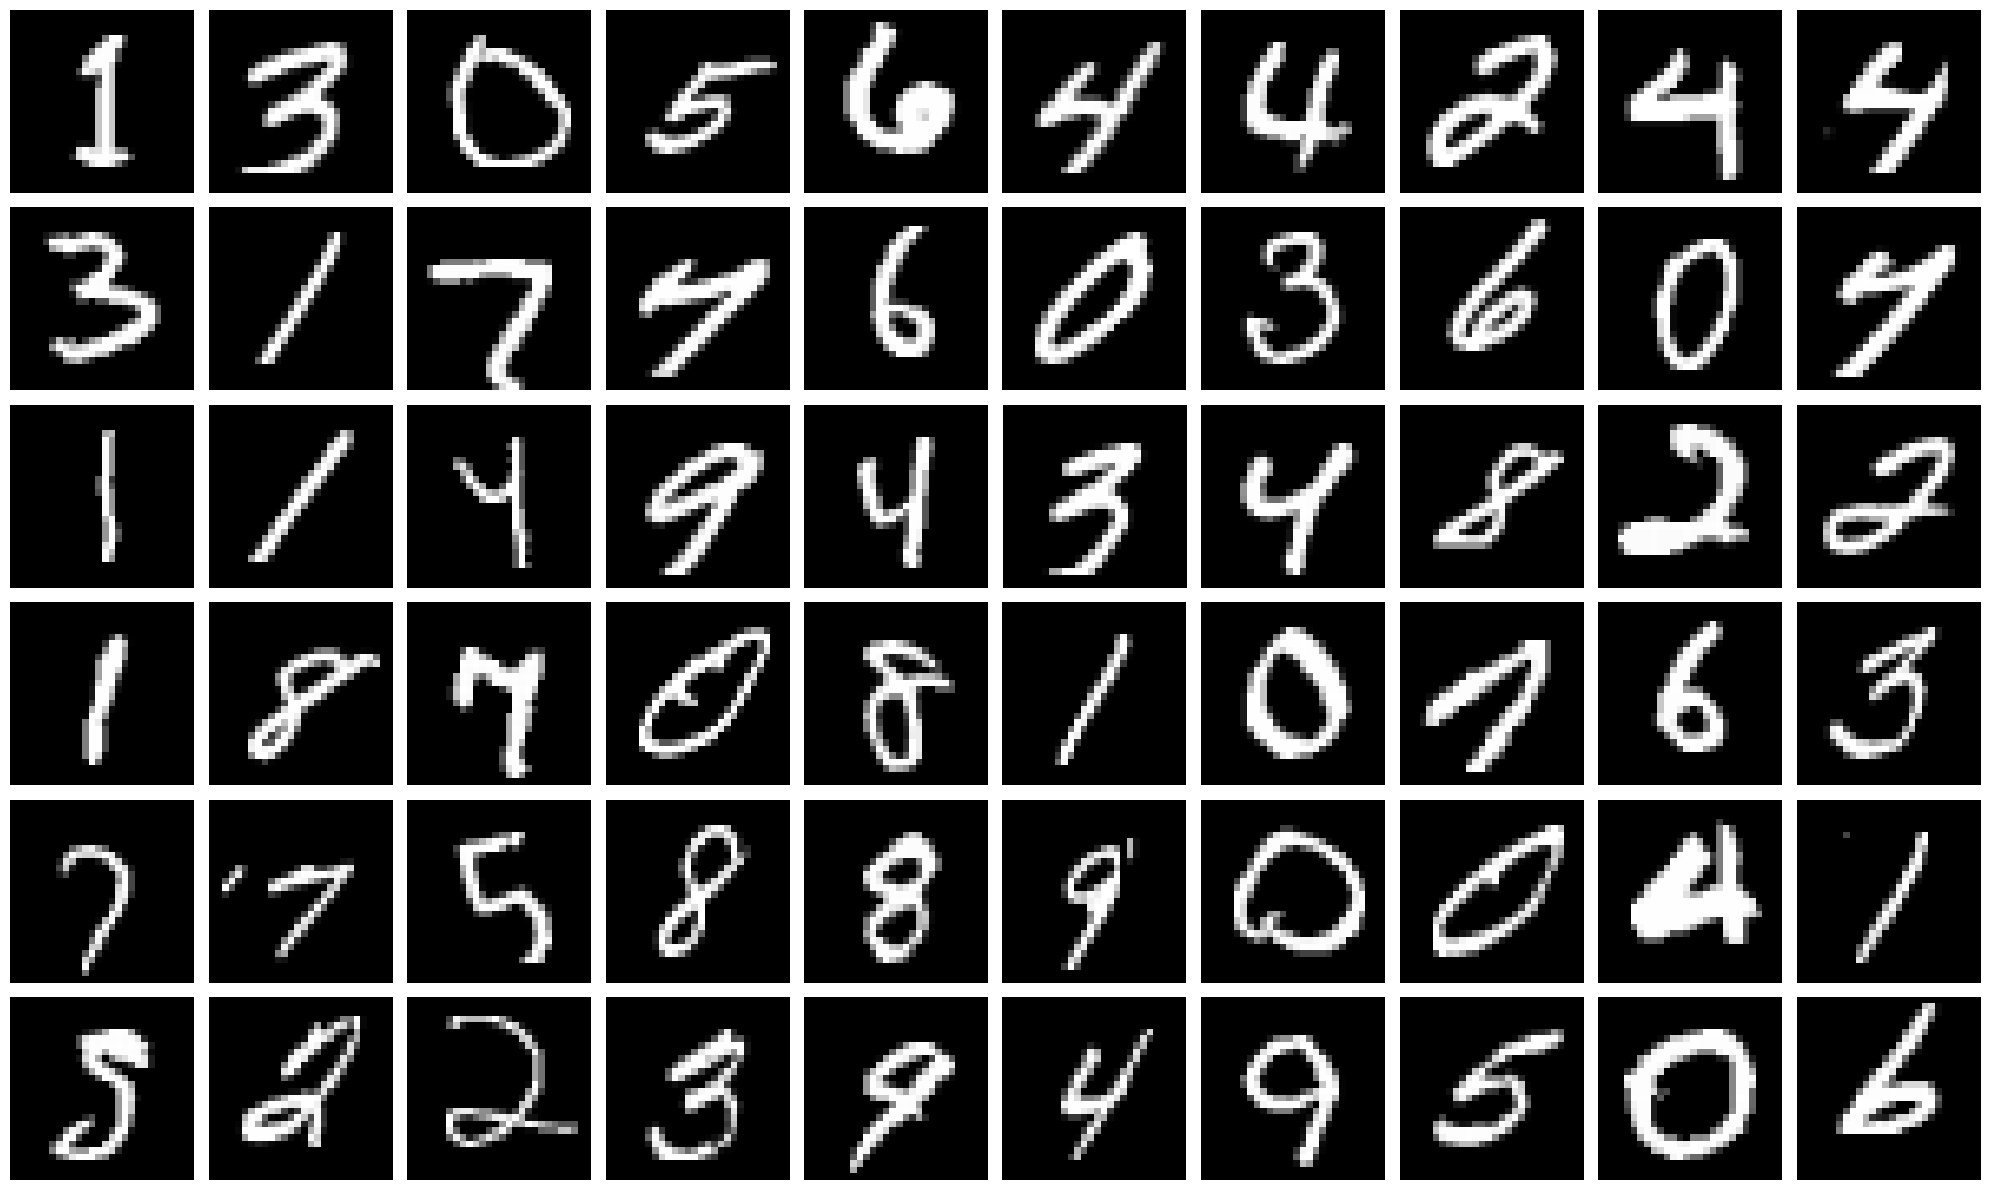

In [2]:
import matplotlib.pyplot as plt

# Función auxiliar para visualización de los datos
def print_numbers(start_index: int = 0) -> None:
    fig, axes = plt.subplots(6, 10, figsize=(20, 12))  # 3 filas, 5 columnas

    for i, ax in enumerate(axes.flat):
        index = start_index + i
        ax.imshow(digit_train[index], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print_numbers(982)

---
## Transformación de datos

Los arreglos de `digit_train` y `label_train` deben ser transformados para el entrenamiento. El objetivo es que los valores de iluminación (siendo 0 completamente oscuro y 1 completamente blanco) de los pixeles de los dígitos sean los valores de entrada. Para un grid de 28x28 pixeles, eso significa que la capa de entrada tiene 784 neuronas. Por otro lado, la capa de salida será de 10 neuronas; de la cual se espera una esté encendida y el resto apagada, indicando el dígito reconocido. Para comparar el error durante el entrenamiento y las pruebas, se tiene que hacer un one-hot encoding de los labels.

In [3]:
from pipeline import Transformer

X_vectors = Transformer.transform_digits(digit_train) # Vector con los pixeles
Y_vectors = Transformer.transform_labels(label_train) # Vector con los catálogos (one-hot encoding)

print(X_vectors.shape)
print(Y_vectors.shape)

(60000, 784)
(60000, 10)


In [13]:
# Viendo uno de los elementos de pixel_vectors, veremos que la dimensión del elemento es de 784
print(X_vectors[0].shape)

# Viendo uno de los elementos de label_vectors, veremos que es un vector con un solo 1 y el resto cero.
print(Y_vectors[0])

(784,)
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


El primer digito del set es el número cinco. En el caso del one-hot encoding, se observa como el sexto componente es el que posee el $1$. Esto es porque, se empieza a contar desde $0$ hasta $9$, por lo que el sexto componente es el que corresponde a $5$.

---
## Construcción de la red neuronal

La red neuronal tendrá la siguiente forma:

| Capa           | Neuronas | Función de activación |
| -------------- | -------- | --------------------- |
| Entrada        | 784      |                       |
| 1a capa oculta | 128      | ReLU                  |
| 2a capa oculta | 64       | ReLU                  |
| Salida         | 10       | Sigmoide              |

### Inicialización

Para contruir la red neuronal, se estará dependiendo fuertemente de `Numpy` para poder trabajar operaciones con matrices y vectores. Los parámetros en los que se tiene control son los pesos $\mathbf{W}^{(l)}$ y los sesgos $\mathbf{b}^{(l)}$. Los sesgos, por ningún motivo en particular, se inicializan todos como cero (puede verse como una red con neuronas imparciales). Los pesos, por otro lado, se inicializan por medio de un método llamado "He":

$$W\to\mathcal{N}\left( 0, \sqrt{ \frac{2}{n} } \right)$$

La inicialización He consiste en utilizar un número aleatorio siguiendo la distribución gaussiana entre 0 y $\sqrt{2/n}$; y este proceso de se hace porque, inicializar los pesos en cero no permiten el aprendizaje pues todas las señales son cero, pero si son números muy grandes, entonces los números resultantes llegan a ser demasiado grandes. Entonces, se parte de números aleatorios cercanos a cero.

In [4]:
rng = np.random.default_rng()

# pesos
W1 = rng.normal(0, np.sqrt(2/784), (784, 128))
W2 = rng.normal(0, np.sqrt(2/128), (128, 64))
W3 = rng.normal(0, np.sqrt(2/64), (64, 10))

# sesgos
b1 = np.zeros(128)
b2 = np.zeros(64)
b3 = np.zeros(10)

### Forward

El proceso `forward` es el que toma una entrada puntual en la capa de entrada, manda las señales a la siguiente capa, cada señal multiplicada por el peso de la conexión y luego realiza la suma ponderada agregando el sesgo. Para ello, la entrada es multiplicado por una matriz de pesos $\mathbf{W}^{(1)}$ y al vector resultante se le suma un vector de sesgos $\mathbf{b}^{(1)}$. Esto da como resultado una función auxiliar:

$$ \mathbf{z}^{(l)}=\mathbf{W}^{(l)} \mathbf{a}^{(l-1)} + \mathbf{b}^{(l)} $$

El resultado de esta se guardará con el propósito de usarle en retropropagación, al igual que los vectores de los valores de activación $\mathbf{a}^{(l)}$.

In [5]:
# Funciones de activación
def relu(x): 
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [6]:
def forward(x):
    
    # De entrada a primera capa
    z1 = x @ W1 + b1
    a1 = relu(z1) # Activación primera capa

    # De primera a segunda capa
    z2 = a1 @ W2 + b2
    a2 = relu(z2) # Activación segunda capa

    # De segunda a tercera capa (salida)
    z3 = a2 @ W3 + b3
    a3 = sigmoid(z3) # Activación tercera capa (salida)

    return z1, z2, z3, a1, a2, a3

aux1, aux2, aux3, act1, act2, act3 = forward(X_vectors[0])
print(act3)

[0.38942369 0.63948138 0.48547568 0.43459672 0.61609166 0.50980711
 0.46491435 0.4972172  0.36365211 0.40396895]


### Función de costo

La función de costo es una que, implícitamente, tiene como parámetros a los pesos y sesgos; y el resultado de esta es un número real que indica el grado de error que tiene la red neuronal para todos los datos del set de entrenamiento. Para este caso particular, la función de costo es el Error Cuadrático Medio (MSE):
$$C(\mathbf{w}, \mathbf{b}) = \frac{1}{2n} \sum^{n-1}_{i=0}(\mathbf{y}_{i} - \mathbf{a}^{(3)})^{2}$$

La razón de tener el $1/2n$ en vez de $1/n$ es porque, la derivada de la función de costo será $(\mathbf{y}_{i} - \mathbf{a}^{(3)})$, ya que el dos del exponente se cancela con la fracción.

In [7]:
def mean_square_error(X_input, Y_expected):
    Y_real = []

    for x in X_input:
        output = forward(x)
        Y_real.append(output[5])
        
    Y_real = np.array(Y_real)
    
    return np.mean((Y_real - Y_expected) ** 2) / 2

print(mean_square_error(X_vectors, Y_vectors))

0.1268520579934357


---
## Entrenamiento

### Retropropagación
El método de retropropagación es uno que, si bien concepualmente es un poco complicado, ya con las fórmulas sale relativamente sencillo ya que la función a plantear solo funciona con datos puntuales. Los deltas $\delta^{(l)}$ se pueden calcular secuencialmente, para luego operarlos con las derivadas respectivas de los pesos $\mathbf{w}_{jk}^{(l)}$ y de los sesgos $\mathbf{b}_{j}^{(l)}$. Recordando la fórmula de la retropropagación:

$$\delta^{(l-1)} = (\mathbf{W}^{(l)})^{\intercal}\, \delta^{(l)} \odot f'(z^{(l-1)})$$

Observamos que se tiene que operar con las derivadas de las funciones de activación. Ya que estamos trabajando con dos, es necesario identificar cuándo trabajar con cual.
- La función sigmoide $\sigma(x)$ tiene como derivada a $\sigma'(x) = \sigma(x) (1-\sigma(x))$. Esto es porque la función sigmoide al fin y al cabo es una forma exponencial:
$$ \sigma(x) = \frac{1}{1+e^{-x}} $$
- La función ReLU es un caso especial, porque su derivada de $(-\infty, 0)$ es $0$, y su derivada desde $(0, +\infty)$ es $1$. Esto es porque $ReLU(x) = \max(0, x)$. Sin embargo, ReLU no es diferenciable en $x=0$... Pero al final, no importa mucho qué pasa si resulta que $x$ termina en cero, así que se dice que la derivada de ReLU es la función escalón.
$$ ReLU'(x) = \begin{cases} 1 \, x > 0 \\ 0 \, x \leq 0 \end{cases}$$

In [8]:
# Derivadas de las funciones de activación
def d_relu(x):
    return (x > 0).astype(float)

def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

In [9]:
def backpropagation(x, y_expected):
    z1, z2, z3, a1, a2, a3 = forward(x)
    
    delta_3 = (a3 - y_expected) * d_sigmoid(z3)
    delta_2 = (delta_3 @ W3.T) * d_relu(z2)
    delta_1 = (delta_2 @ W2.T) * d_relu(z1)
    
    d_W3 = np.outer(a2, delta_3)
    d_W2 = np.outer(a1, delta_2)
    d_W1 = np.outer(x, delta_1)
    
    # La derivada de los sesgos es 1, así que son iguales a los deltas
    return d_W3, d_W2, d_W1, delta_3, delta_2, delta_1

### Gradiente
La función de retropropagación actual solo realiza el proceso para un dato puntual. Para obtener el verdadero gradiente de la función de costo, se tiene que sacar el promedio del resultado de la retropropagación para todos los datos. Por ejemplo, para obtener uno de los componentes del gradiente, que es la derivada de la función de costo $C$ con respecto a un peso $w_{jk}^{(l)}$:

$$ \frac{ \partial C }{ \partial w_{jk}^{(l)} } = \frac{1}{n} \sum^{n-1}_{i=0} \frac{ \partial C_{i} }{ \partial w_{jk}^{(l)} }$$

In [10]:
sum_d_W3 = np.zeros_like(W3)
sum_d_W2 = np.zeros_like(W2)
sum_d_W1 = np.zeros_like(W1)

sum_d_b3 = np.zeros_like(b3)
sum_d_b2 = np.zeros_like(b2)
sum_d_b1 = np.zeros_like(b1)

for x, y in zip(X_vectors, Y_vectors):
    d_W3, d_W2, d_W1, d_b3, d_b2, d_b1 = backpropagation(x, y)
    
    sum_d_W3 += d_W3
    sum_d_W2 += d_W2
    sum_d_W1 += d_W1

    sum_d_b3 += d_b3
    sum_d_b2 += d_b2
    sum_d_b1 += d_b1

set_size = len(X_vectors)

sum_d_W3 /= set_size
sum_d_W2 /= set_size
sum_d_W1 /= set_size

sum_d_b3 /= set_size
sum_d_b2 /= set_size
sum_d_b1 /= set_size

### Descenso de gradiente

Ahora, solo queda ajustar los pesos y sesgos, con respecto a una tasa de aprendizaje. Usualmente, suele ser un paso relativamente pequeño como $0.01$, pero es posible probar diferentes tasas de aprendizaje para obtener un resultado más óptimo. En mi caso, sin ninguna razón en particular, tomaré el valor $0.05$. Recordando la fórmula recursiva para el descenso de gradiente:

$$ \omega_{k+1}=\omega _{k}-\alpha\cdot \nabla f(\omega_{k}) $$

Para calcular el siguiente vector $\omega_{k+1}$, se parte de un vector $\omega_{k}$ que se ajusta un pequeño paso $\alpha$ (tasa de aprendizaje) en dirección opuesta al gradiente evaludo en $\omega_{k}$.

In [21]:
learning_rate = 0.05

W3 -= learning_rate * sum_d_W3
W2 -= learning_rate * sum_d_W2
W1 -= learning_rate * sum_d_W1

b3 -= learning_rate * sum_d_b3
b2 -= learning_rate * sum_d_b2
b1 -= learning_rate * sum_d_b1

# Veremos que el costo ha disminuído un poco
print(mean_square_error(X_vectors, Y_vectors))

0.10782853877569061


### Epochs

Todo este proceso sirvió para minimizar la función de costo en un solo paso. Esto quiere decir que es muy posible que la función no se encuentre en un mínimo, a pesar de que a la red neuronal le esté yendo mejor comparado a en su inicialización.

Es por eso que todo este procedimiento tiene que repetirse varias veces, y a estas repeticiones se les llama epochs. Hasta ahora, el proceso de entrenamiento se ha realizado paso por paso con fines demostrativos. En la celda a continuación se engloba todo el proceso para poder iterarlo después.

In [22]:
epochs = 29
learning_rate=0.05

def get_gradient(X, Y_expected):    
    sum_d_W3 = np.zeros_like(W3)
    sum_d_W2 = np.zeros_like(W2)
    sum_d_W1 = np.zeros_like(W1)

    sum_d_b3 = np.zeros_like(b3)
    sum_d_b2 = np.zeros_like(b2)
    sum_d_b1 = np.zeros_like(b1)

    for x, y in zip(X, Y_expected):
        d_W3, d_W2, d_W1, d_b3, d_b2, d_b1 = backpropagation(x, y)

        sum_d_W3 += d_W3
        sum_d_W2 += d_W2
        sum_d_W1 += d_W1

        sum_d_b3 += d_b3
        sum_d_b2 += d_b2
        sum_d_b1 += d_b1

    set_size = len(X_vectors)

    # Gradiente real
    sum_d_W3 /= set_size
    sum_d_W2 /= set_size
    sum_d_W1 /= set_size

    sum_d_b3 /= set_size
    sum_d_b2 /= set_size
    sum_d_b1 /= set_size
        
    return sum_d_W3, sum_d_W2, sum_d_W1, sum_d_b3, sum_d_b2, sum_d_b1


for i in range(epochs-1):
    gradient = get_gradient(X_vectors, Y_vectors)
        
    # Descenso de gradiente
    W3 -= learning_rate * gradient[0]
    W2 -= learning_rate * gradient[1]
    W1 -= learning_rate * gradient[2]

    b3 -= learning_rate * gradient[3]
    b2 -= learning_rate * gradient[4]
    b1 -= learning_rate * gradient[5]

print(mean_square_error(X_vectors, Y_vectors))

0.0458155801591536


### Pruebas

Cargamos el set de pruebas:

In [11]:
digit_test = Loader.load_mnist_images("mnist-dataset/t10k-images.idx3-ubyte")
label_test = Loader.load_mnist_labels("mnist-dataset/t10k-labels.idx1-ubyte")

pixel_vectors_test = Transformer.transform_digits(digit_test)
label_vectors_test = Transformer.transform_labels(label_test)

La función de costo es una forma de ver qué tan bien le va a la red neuronal, pero su principal uso es para el entrenamiento. Una métrica de evaluación más efectiva es la *exactitud*. Esta métrica es sencilla, es la razón que hay entre predicciones o evaluaciones correctas del total del conjunto de datos.
$$\text{accuracy}=\frac{\text{evaluaciones correctas}}{\text{evaluaciones totales}}$$

In [12]:
# La obtención de las evaluaciones de la red neuronal se hicieron anteriormente
def test_accuracy(X_input, Y_expected):
    Y_real = []

    for x in X_input:
        output = forward(x)
        Y_real.append(output[5])
        
    Y_real = np.array(Y_real)
    
    correct = 0
    total = 0

    for y_real, y_expected in zip(Y_real, Y_expected):
        predicted_label = np.argmax(y_real)
        expected_label = np.argmax(y_expected)
        
        if (predicted_label == expected_label):
            correct += 1
        
        total += 1
        
    accuracy = correct / total
    print(accuracy)
    
print(test_accuracy(pixel_vectors_test, label_vectors_test))

0.131
None


### Optimización

Incluso después de 30 epochs, vemos que con el propio set de entrenamiento, a la red neuronal no le está yendo bien. Entonces, parece ser que el método de aprendizaje no es los suficientemente bueno. Hay varias formas en las que se puede mejorar el entrenamiento, especialmente con el descenso de gradiente ya que, vemos que el entrenamiento es algo largo y puede que se quede estancado en un mínimo local que no sea muy óptimo.
- Trabajar con descenso de gradiente con momento, para mejorar la minimización del costo.
- Trabajar con descenso de gradiente estocástico, para acelerar la minimización del costo.

#### Descenso de gradiente con momento
Reiniciamos a la red neuronal... Y para trabajar con momento, llevaremos el seguimiento de nuevas variables de "velocidad".

In [25]:
# pesos
W1 = rng.normal(0, np.sqrt(2/784), (784, 128))
W2 = rng.normal(0, np.sqrt(2/128), (128, 64))
W3 = rng.normal(0, np.sqrt(2/64), (64, 10))

# sesgos
b1 = np.zeros(128)
b2 = np.zeros(64)
b3 = np.zeros(10)

# velocidades
vW1 = np.zeros_like(W1)
vW2 = np.zeros_like(W2)
vW3 = np.zeros_like(W3)

vb1 = np.zeros_like(b1)
vb2 = np.zeros_like(b2)
vb3 = np.zeros_like(b3)

# El resultado, ya que la red ha sido reiniciada, debería ser basura.
output = forward(X_vectors[0])
print(output[5])

[0.56178164 0.49080606 0.51551539 0.4336829  0.48704993 0.31098161
 0.57044509 0.2113461  0.54693902 0.61497688]


El descenso de gradiente con momento añade una velocidad al paso, así que en caso de que el método normal nos guíe a un mínimo local "poco profundo", la velocidad acumulada de los pasos permite escapar de este mínimo para buscar uno que sea más óptimo.

$$
\begin{align*}
v_{t} &= \beta v_{t-1} + (1-\beta) \nabla \theta(\omega_t) \\
\omega_{t+1} &= \omega_t - \alpha v_t
\end{align*}
$$

La cantidad de velocidad que se acumula por paso es determinado por un momento $\beta$, que suele ser un número algo elevado comparado con la tasa de aprendizaje $\alpha$, pero siempre sigue siendo menor que 1.

In [26]:
epochs = 30
learning_rate=0.05
momentum = 0.9

for i in range(epochs-1):
    gradient = get_gradient(X_vectors, Y_vectors) 
        
    vW3 = momentum * vW3 - learning_rate * gradient[0]
    vW2 = momentum * vW2 - learning_rate * gradient[1]
    vW1 = momentum * vW1 - learning_rate * gradient[2]

    vb3 = momentum * vb3 - learning_rate * gradient[3]
    vb2 = momentum * vb2 - learning_rate * gradient[4]
    vb1 = momentum * vb1 - learning_rate * gradient[5]

    W1 += vW1
    W2 += vW2
    W3 += vW3

    b1 += vb1
    b2 += vb2
    b3 += vb3
    
print(mean_square_error(X_vectors, Y_vectors))
print(test_accuracy(pixel_vectors_test, label_vectors_test))

0.04948157576604125
0.158
None


#### Descenso de gradiente estocástico

Si bien el descenso de gradiente con momento puede ayudar, el cambio no es significativo; pues el tiempo de computo para hacer 30 epochs (30 pasos) es demasiado grande. Toma alrededor de 6 minutos con una computadora potente entrenar a la red neuronal. El método de descenso de gradiente estocástico lo que hace es ahorrarse el trabajo de computo de obtener el gradiente real, y decide hacer una estimación.

Para ello, realiza el ajuste en el gradiente en base a la retropropagación de un dato puntual. Esto hace que el descenso de gradiente sea más ruidoso, pero más rápido. Para balancear el ruido del descenso de gradiente puro, una mejor técnica es subdividir el set de entrenamiento en pequeñas muestras, y en base al gradiente estimado realiza el ajuste. Esta técnica es denominada *mini-batches*.

In [13]:
# REINICIO DE LA RED NEURONAL
W1 = rng.normal(0, np.sqrt(2/784), (784, 128))
W2 = rng.normal(0, np.sqrt(2/128), (128, 64))
W3 = rng.normal(0, np.sqrt(2/64), (64, 10))

b1 = np.zeros(128)
b2 = np.zeros(64)
b3 = np.zeros(10)

# velocidades
vW1 = np.zeros_like(W1)
vW2 = np.zeros_like(W2)
vW3 = np.zeros_like(W3)

vb1 = np.zeros_like(b1)
vb2 = np.zeros_like(b2)
vb3 = np.zeros_like(b3)

output = forward(X_vectors[0])
print(output[5])

[0.52052142 0.35269488 0.47327124 0.55869594 0.26295887 0.47614539
 0.61501233 0.64035902 0.40085323 0.49127159]


El entrenamiento no cambia mucho, solo unas cuantas variables renombradas:

In [14]:
def estochastic_gradient(X_batch, Y_expected_batch):

    batch_size = X_batch.shape[0]

    sum_d_W3 = np.zeros_like(W3)
    sum_d_W2 = np.zeros_like(W2)
    sum_d_W1 = np.zeros_like(W1)

    sum_d_b3 = np.zeros_like(b3)
    sum_d_b2 = np.zeros_like(b2)
    sum_d_b1 = np.zeros_like(b1)

    for x, y in zip(X_batch, Y_expected_batch):
        d_W3, d_W2, d_W1, d_b3, d_b2, d_b1 = backpropagation(x, y)

        sum_d_W3 += d_W3
        sum_d_W2 += d_W2
        sum_d_W1 += d_W1

        sum_d_b3 += d_b3
        sum_d_b2 += d_b2
        sum_d_b1 += d_b1

    # Gradiente real
    sum_d_W3 /= batch_size
    sum_d_W2 /= batch_size
    sum_d_W1 /= batch_size

    sum_d_b3 /= batch_size
    sum_d_b2 /= batch_size
    sum_d_b1 /= batch_size
        
    return sum_d_W3, sum_d_W2, sum_d_W1, sum_d_b3, sum_d_b2, sum_d_b1

Ahora, si bien la celda tomará el mismo tiempo pues, como con los ejemplos anteriores, se recorre el set de entrenamiento entero 30 veces; esta vez el tiempo invertido será más fructífero. Esto es porque, la estimación del gradiente se hace por cada muestra de 100 datos, en vez de obtener el gradiente completo con los 60,000 datos. Esto hace que, si bien la estimación del gradiente no sea la mejor, se realizan un total de 18,000 pasos en el gradiente.

In [15]:
epochs = 30
learning_rate=0.05
momentum = 0.9

batch_size = 100

for i in range(epochs-1):
    for j in range (0, len(X_vectors), batch_size):
        X_batch = X_vectors[j: j+batch_size]
        Y_batch = Y_vectors[j: j+batch_size]

        gradient = estochastic_gradient(X_batch, Y_batch) 
            
        vW3 = momentum * vW3 - learning_rate * gradient[0]
        vW2 = momentum * vW2 - learning_rate * gradient[1]
        vW1 = momentum * vW1 - learning_rate * gradient[2]

        vb3 = momentum * vb3 - learning_rate * gradient[3]
        vb2 = momentum * vb2 - learning_rate * gradient[4]
        vb1 = momentum * vb1 - learning_rate * gradient[5]

        W1 += vW1
        W2 += vW2
        W3 += vW3

        b1 += vb1
        b2 += vb2
        b3 += vb3

print(mean_square_error(X_vectors, Y_vectors))
print(test_accuracy(pixel_vectors_test, label_vectors_test))

0.0007263453263445975
0.9766
None


Hay que considerar que 18,000 pasos puede ser algo excesivo, pues puede llevar a un sobreajuste. Sin embargo, al realizar las pruebas con el set de pruebas, que son datos que en teoría nunca ha visto; vemos cómo el desempeño de la red aumentó dramáticamente a alrededor de un 97% de exactitud.

### Misceláneo
Con ayuda de Chat GPT, generé una aplicación que permita ver a la red neuronal evaluando los dígitos manuscritos en tiempo real, comparando con el valor esperado. No es una forma de evaluación efectiva, pues hay un tiempo por cada uno de los ejemplos y se va uno por uno... Pero es bastante buena para una demostración visual.

In [37]:
import gradio as gr
import time

# Para mayor variedad, se desordenan los datos
perm = np.random.permutation(len(pixel_vectors_test))

pixel_vectors_test = pixel_vectors_test[perm]
label_vectors_test = label_vectors_test[perm]

custom_css = """
.big-text { font-size: 32px !important; line-height: 1.2 !important; }
.metric-text { font-size: 28px !important; }
.status-card { padding: 20px; border-radius: 10px; margin-bottom: 20px; }
#image-container { height: 450px !important; width: 450px !important; margin: auto; }
"""

def start_evaluation():
    correct = 0
    total = 0
    
    # Asegúrate de que pixel_vectors_test y label_vectors_test estén accesibles
    for i in range(len(pixel_vectors_test)):
        x_input = pixel_vectors_test[i]
        
        # Inferencia con tu clase Perceptron
        output = forward(x_input)
        probs = output[5]
        predicted_label = np.argmax(probs)
        certainty = output[5][predicted_label] * 100
        true_label = np.argmax(label_vectors_test[i])
        
        total += 1
        is_error = (predicted_label != true_label)
        if not is_error:
            correct += 1
        
        accuracy = (correct / total) * 100
        
        # 28x28 para visualización
        img_view = x_input.reshape(28, 28)
        img_view = np.kron(img_view, np.ones((20,20)))
        
        status_color = "<span style='color: #e06666'>ERROR</span>" if is_error else "<span style='color: #93c47d'>CORRECTO</span>"
        
        # Construcción del HTML para la presentación
        status_html = f"""
        <div class='status-card'>
            <p class='big-text'><b>Estado:</b> {status_color}</p>
            <p class='big-text'><b>Valor real:</b> <span style='color: #2563eb'>{true_label}</span></p>
            <p class='big-text'><b>Valor detectado:</b> <span style='color: #d97706'>{predicted_label}</span></p>
            <p class='big-text'><b>Certeza de detección:</b> <span style='color: #d97706'>{certainty:.0f}%</span></p>
        </div>
        """
        
        metrics_html = f"""
        <div class='metric-text'>
            <p><b>Accuracy:</b> {accuracy:.2f}%</p>
        </div>
        """

        yield img_view, status_html, metrics_html
        
        time.sleep(2.5 if is_error else 0.5)

# --- Construcción de la Interfaz ---

# Quitamos 'css' de aquí por el Warning
with gr.Blocks(title="MNIST Presentation") as demo:
    with gr.Row(variant="compact"):
        with gr.Column(scale=1, variant="panel"):
            # Quitamos 'show_download_button' que causaba el TypeError
            image_output = gr.Image(
                show_label=False,
                image_mode="L", 
                elem_id="image-container",
                buttons=[]
            )
            
        with gr.Column(scale=1, variant="compact"):
            status_output = gr.HTML("<div class='big-text'>Esperando inicio...</div>")
            metrics_output = gr.HTML()
            
    btn_run = gr.Button("🚀 INICIAR EVALUACIÓN", variant="primary", size="lg")

    btn_run.click(
        fn=start_evaluation,
        outputs=[image_output, status_output, metrics_output]
    )

if __name__ == "__main__":
    demo.launch(css=custom_css, theme=gr.themes.Monochrome())

* Running on local URL:  http://127.0.0.1:7878
* To create a public link, set `share=True` in `launch()`.
